# 2) 抓取物体（又称逆几何）

## Objectives  目标


本教程的主要目标是计算机器人的一种配置，该配置能够最小化成本（最大化奖励）并满足某些给定的约束条件。此外，目标还包括初步体验在真实向量空间之外工作的困难，并思考最优求解器所采用的猜测是什么。



2.0) 技术先决条件


Python SciPy 与 MatplotLib


您需要两个 Python 库：SciPy（科学计算库）和 MatPlotLib（数学数据绘图库）。



SciPy 可通过 sudo apt-get install python-scipy 安装。下方给出了这两个函数调用的示例。我们将使用两种求解器配合数值（有限差分）微分，以避免手动对成本和约束函数进行微分的额外工作。通常强烈建议先使用有限差分测试数值程序，仅在必要时才实现真实导数。无论如何，必须始终通过将结果与有限差分结果进行比较来验证真实导数的正确性。



此外，提供的 BFGS 实现允许用户提供回调函数并跟踪求解器的求解路径，但不支持指定约束条件（约束可以作为惩罚函数添加到成本函数中，但这需要额外工作）。约束最小二乘实现允许用户指定等式和不等式约束，但不支持回调功能。在后续操作中，请先使用 BFGS 方法，仅在确实需要约束条件时才转向约束最小二乘法。



In [1]:
# Example of use a the optimization toolbox of SciPy.
# SciPy 优化工具箱使用示例。

import numpy as np
from scipy.optimize import fmin_bfgs, fmin_slsqp

def cost(x):
    '''Cost f(x, y) = x² + 2y² - 2xy - 2x '''
    '''代价函数 f(x, y) = x² + 2y² - 2xy - 2x '''
    x0, x1 = x
    return -(2 * x0 * x1 + 2 * x0 - x0 ** 2 - 2 * x1 ** 2)

def constraint_eq(x):
    ''' Constraint x³ = y '''
    ''' 约束条件 x³ = y '''
    return np.array([ x[0] ** 3 - x[1] ])

def constraint_ineq(x):
    '''Constraint x >= 2, y >= 2'''
    '''约束条件 x >= 2, y >= 2'''
    return np.array([ x[0] - 2, x[1] - 2 ])

class CallbackLogger:
    def __init__(self):
        self.nfeval = 1

    def __call__(self,x):
        print('===CBK=== {0:4d} {1: 3.6f} {2: 3.6f} {3: 3.6f}'.format(self.nfeval, x[0], x[1], cost(x)))
        self.nfeval += 1

x0 = np.array([0.0, 0.0])  # Optimize cost without any constraints in BFGS, with traces.
x0 = np.array([0.0, 0.0])  # 在 BFGS 中无约束优化成本，并带有跟踪。
xopt_bfgs = fmin_bfgs(cost, x0, callback=CallbackLogger())
print('*** Xopt in BFGS =', xopt_bfgs)

# Optimize cost without any constraints in CLSQ
# 在 CLSQ 中无约束优化成本

xopt_lsq = fmin_slsqp(cost, [-1.0, 1.0], iprint=2, full_output=1)
print('*** Xopt in LSQ =', xopt_lsq)

# Optimize cost with equality and inequality constraints in CLSQ
# 在 CLSQ 中使用等式和不等式约束优化成本

xopt_clsq = fmin_slsqp(cost, [-1.0, 1.0], f_eqcons=constraint_eq, f_ieqcons=constraint_ineq, iprint=2, full_output=1)
print('*** Xopt in c-lsq =', xopt_clsq)
print('*** 在 c-lsq 中的 Xopt =', xopt_clsq)

===CBK===    1  1.010000 -0.000000 -0.999900
===CBK===    2  2.014799  1.009848 -1.999878
===CBK===    3  2.000000  1.000000 -2.000000
Optimization terminated successfully.
         Current function value: -2.000000
         Iterations: 3
         Function evaluations: 12
         Gradient evaluations: 4
*** Xopt in BFGS = [1.99999977 0.99999994]
  NIT    FC           OBJFUN            GNORM
    1     4     1.150000E+02     8.485281E+00
    2     8    -1.928000E+00     1.697056E+00
    3    11    -2.000000E+00     3.394113E-01
    4    13    -2.000000E+00     2.980232E-08
Optimization terminated successfully    (Exit mode 0)
            Current function value: -2.0
            Iterations: 4
            Function evaluations: 13
            Gradient evaluations: 4
*** Xopt in LSQ = (array([1.99999999, 1.        ]), -2.0, 4, 0, 'Optimization terminated successfully')
  NIT    FC           OBJFUN            GNORM
    1     4     9.600000E+01     8.485281E+00
    2     7     9.600000E+01   

请注意，SciPy 始终使用一维数组表示向量，而 Pinocchio 使用矩阵表示向量（实际上是二维数组，其中第二维为 1）。您可以通过以下方式将 SciPy 风格的向量转换为 Pinocchio 风格的向量：



In [31]:
import numpy as np
x = np.array([1.0, 2.0, 3.0])
q = np.array(x)
x = q.reshape(-1, 1)
x.shape


(3, 1)

第二个库 MatPlotLib 用于在二维图表上绘制数值。此处提供了一份教程。下面是一个示例。



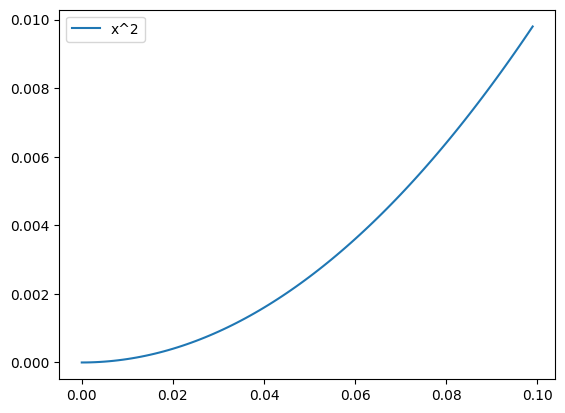

In [32]:
import numpy as np
import matplotlib.pyplot as plt
# In plt, the following functions are the most useful:
# 在 plt 中，以下函数最为实用：
# ion, plot, draw, show, subplot, figure, title, savefig
# 导入、绘图、绘制、显示、子图、图形、标题、保存图形

# For use in interactive python mode (ipthyon -i)
# 用于交互式 Python 模式（ipython -i）
interactivePlot = False

if interactivePlot:
    plt.ion()  # Plot functions now instantaneously display, shell is not blocked
plt.ion()  # 绘图函数现在会即时显示，不会阻塞 shell

# Build numpy array for x axis
# 为 x 轴构建 numpy 数组
x = 1e-3 * np.array(range(100))
# Build numpy array for y axis
# 为 y 轴构建 numpy 数组
y = x ** 2

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x, y)
ax.legend(("x^2", ))

if not interactivePlot:
    # Display all the plots and block the shell.
# 显示所有图表并阻塞 shell。
    # The script will only ends when all windows are closed.
# 脚本仅在所有窗口关闭后才会结束。
    plt.show()

## Robots  机器人


我们这里主要使用 UR5 模型，该模型在第一次实验中已使用。请参考实验 1 的说明来加载它。



可选地，我们可能希望使用一个更复杂的机器人模型。Romeo 是由法日合资公司 Aldebaran Robotics 开发的人形机器人。它拥有两条腿、两只手臂和一个头部，总共 31 个关节（外加自由飞行器的 6 个自由度）。Romeo 的描述可以通过以下方式获取：



可以通过以下方式加载 Romeo：



In [2]:
from os.path import join
import pinocchio as se3
from pinocchio.romeo_wrapper import RomeoWrapper

PKG = '/opt/openrobots/share'
URDF = join(PKG, 'example-robot-data/robots/romeo_description/urdf/romeo.urdf')
# URDF = join(PKG, 'example-robot-data/robots/ur_description/urdf/ur5_robot.urdf')
robot = RomeoWrapper(URDF, [PKG])  # Load urdf model
robot = RomeoWrapper(URDF, [PKG])  # 加载 urdf 模型
from pinocchio.visualize import GepettoVisualizer, MeshcatVisualizer
VISUALIZER = GepettoVisualizer
robot.setVisualizer(VISUALIZER())
robot.initViewer(loadModel=True)
# robot.loadViewerModel("pinocchio")
from pinocchio.utils import *
q = zero(robot.nq)
robot.display(q)

此外，右手、左手、右脚和左脚的索引分别存储在 robot.rh 、 robot.lh 、 robot.rf 和 robot.lf 中。



第一个教程是将机械臂机器人的末端执行器定位（即仅平移）到指定位置。在这一部分中，我们将使用固定的串联机器人模型。



首先回顾一下，索引为 i 的关节在位置 q 处的（三维）位置可以通过以下两行代码访问：



In [4]:
# Compute all joint placements and put the position of joint "i" in variable "p".
# 计算所有关节位置，并将关节"i"的位置存入变量"p"。
import pinocchio as se3
se3.forwardKinematics(robot.model, robot.data, q)
print(f"robot.model.njoints = {robot.model.njoints}")
for i in range(robot.model.njoints):
    p = robot.data.oMi[i].translation
    print(f"Joint {i}: {p}")


robot.model.njoints = 57
Joint 0: [0. 0. 0.]
Joint 1: [0. 0. 0.]
Joint 2: [ 0.       0.096   -0.20004]
Joint 3: [ 0.       0.096   -0.20004]
Joint 4: [ 0.       0.096   -0.20004]
Joint 5: [ 0.       0.096   -0.52004]
Joint 6: [ 0.       0.096   -0.81004]
Joint 7: [ 0.       0.096   -0.81004]
Joint 8: [ 0.      -0.096   -0.20004]
Joint 9: [ 0.      -0.096   -0.20004]
Joint 10: [ 0.      -0.096   -0.20004]
Joint 11: [ 0.      -0.096   -0.52004]
Joint 12: [ 0.      -0.096   -0.81004]
Joint 13: [ 0.      -0.096   -0.81004]
Joint 14: [0.  0.  0.2]
Joint 15: [0.005 0.19  0.2  ]
Joint 16: [0.005 0.19  0.2  ]
Joint 17: [0.21       0.18999989 0.19999994]
Joint 18: [0.21       0.18999989 0.19999994]
Joint 19: [0.3923     0.18999979 0.19999989]
Joint 20: [0.3923     0.18999979 0.19999989]
Joint 21: [0.3923     0.18999979 0.19999989]
Joint 22: [0.50755    0.18999972 0.20328985]
Joint 23: [0.51636385 0.18999972 0.18738927]
Joint 24: [0.50672994 0.18999973 0.17197174]
Joint 25: [0.49165999 0.1652197

In [43]:
# 打印每个关节的位姿。
print("\nJoint placements:")
for i, (name, oMi) in enumerate(zip(robot.model.names, robot.data.oMi)):
    print(
        "{}  {:<24} : {: .2f} {: .2f} {: .2f}".format(i, name, *oMi.translation.T.flat)
    )


Joint placements:
0  universe                 :  0.00  0.00  0.00
1  root_joint               : -0.41  0.44 -0.97
2  LHipYaw                  : -0.41  0.54 -1.17
3  LHipRoll                 : -0.41  0.54 -1.17
4  LHipPitch                : -0.41  0.54 -1.17
5  LKneePitch               : -0.41  0.54 -1.49
6  LAnklePitch              : -0.41  0.54 -1.78
7  LAnkleRoll               : -0.41  0.54 -1.78
8  RHipYaw                  : -0.41  0.35 -1.17
9  RHipRoll                 : -0.41  0.35 -1.17
10  RHipPitch                : -0.41  0.35 -1.17
11  RKneePitch               : -0.41  0.35 -1.49
12  RAnklePitch              : -0.41  0.35 -1.78
13  RAnkleRoll               : -0.41  0.35 -1.78
14  TrunkYaw                 : -0.41  0.44 -0.77
15  LShoulderPitch           : -0.44  0.63 -0.77
16  LShoulderYaw             : -0.44  0.63 -0.77
17  LElbowRoll               : -0.24  0.67 -0.77
18  LElbowYaw                : -0.24  0.67 -0.77
19  LWristRoll               : -0.06  0.70 -0.77
20  LWristY

### Question 1  问题 1
基于此，构建一个成本函数，使其为末端执行器位置 p 与期望位置 pdes 之间差值的范数。该成本函数接受一个一维数组作为输入，并返回一个浮点数。



### Question 2  问题 2
然后使用 fmin_bfgs 来找到一个配置 q ，使得末端执行器位于位置 pdes 。



In [70]:
# Question 2: use BFGS to find a configuration q that brings the left hand to LHandExp.
from scipy.optimize import fmin_bfgs, fmin_slsqp
pdes = np.array(LHandExp, dtype=float)
# ee_id = getattr(robot, "lh", 28)  # fallback to 28 if robot.lh is unavailable
ee_id = 22
print(f"ee_id = {ee_id}")
LHandExp = p = [0.0, -0.50, 0.5]

def cost(qx):
    se3.forwardKinematics(robot.model, robot.data, qx)
    pcur = robot.data.oMi[ee_id].translation
    err = pcur - pdes
    return float(err.dot(err))  # squared distance

q0 = q.copy()
qopt = fmin_bfgs(cost, q0, disp=True)

se3.forwardKinematics(robot.model, robot.data, qopt)
popt = robot.data.oMi[ee_id].translation

print("qopt shape:", qopt.shape)
print("Target position pdes :", pdes)
print("Reached position popt:", popt)
print("Final cost:", cost(qopt))

robot.display(qopt)

ee_id = 22
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 9
         Function evaluations: 630
         Gradient evaluations: 10
qopt shape: (62,)
Target position pdes : [ 0.  -0.5  0.5]
Reached position popt: [-1.33764051e-07 -5.00001081e-01  5.00000377e-01]
Final cost: 1.328466607170087e-12


### Question 3  问题 3
最后，实现一个回调函数，在 Gepetto-Viewer 中显示求解器尝试的每个候选配置。

